# Refined Feature-Rich MF6 Workflow

This notebook builds a more realistic synthetic MODFLOW 6 example with a refined Voronoi grid.
Instead of a toy four-cell mesh, it uses `TriangleGrid` to define a rectangular domain, a broad interior refinement zone, a stream-corridor refinement zone, and a finer lake refinement zone before converting the mesh to `VoronoiGridPlus`.

The workflow then adds:

- CHD on the eastern boundary
- DRN from a polygon in the northwest
- GHB from a polygon in the southwest
- recharge zones and UZF
- LAK from a lake polygon
- SFR from a stream line
- region and group registration for later querying


In [1]:
from pathlib import Path
import shutil

import geopandas as gpd
import numpy as np
from shapely.geometry import LineString, Polygon

import simple_modflow as mf
from simple_modflow.modflow.mf6.drn import DRNFromVector
from simple_modflow.modflow.mf6.ghb import GHBFromVector
from simple_modflow.modflow.mf6.lakes import LakeConnectionData, LakePackageData, LakePeriodData
from simple_modflow.modflow.mf6.recharge import RCHFromVector
from simple_modflow.modflow.mf6.sfr import SFR
from simple_modflow.modflow.mf6.uzf import UZFPackageData
from simple_modflow.modflow.mf6.simulation.discretization import DisvGrid, TemporalDiscretization
from simple_modflow.modflow.mf6.simulation.packages import (
    CHD,
    InitialConditions,
    KFlow,
    LAK as LAKPackage,
    OutputControl,
    Recharge,
    Storage,
)


In [2]:
if Path.cwd().name == "notebooks" and Path.cwd().parent.name == "mf6":
    examples_root = Path.cwd().parent
else:
    examples_root = Path.cwd() / "examples" / "mf6"

workspace = examples_root / "artifacts" / "refined_feature_rich_model_workflow"
if workspace.exists():
    shutil.rmtree(workspace, ignore_errors=True)
workspace.mkdir(parents=True, exist_ok=True)

workspace

WindowsPath('c:/Users/lukem/Python/Projects/simple_modflow/examples/mf6/artifacts/refined_feature_rich_model_workflow')

In [3]:
def write_gpkg(path: Path, gdf: gpd.GeoDataFrame) -> Path:
    gdf.to_file(path, driver="GPKG")
    return path


def build_refined_vor(model_ws: Path) -> mf.VoronoiGridPlus:
    triangle_ws = model_ws / "triangle_build"
    triangle_ws.mkdir(parents=True, exist_ok=True)
    tri = mf.TriangleGrid(model_ws=str(triangle_ws))
    tri.set_domain_rectangle(x_dist=2000, y_dist=1500, origin=(0, 0))
    tri.add_region_rectangle(
        origin=(150, 150),
        x_dist=1700,
        y_dist=1200,
        max_area=60000,
        label="mid_refine",
    )
    tri.add_region_polygon(
        LineString([(120, 1100), (1880, 500)]).buffer(75),
        max_area=12000,
        label="stream_refine",
        priority=2,
        source="line",
    )
    tri.add_region_circle(
        center_coords=(700, 500),
        radius=180,
        max_area=5000,
        label="lake_refine",
        priority=3,
    )
    tri.build(verbose=False)

    vor = mf.VoronoiGridPlus(tri)
    top = 135.0 - (0.012 * np.asarray(vor.centroids_x)) + (0.006 * np.asarray(vor.centroids_y))
    bottom = top - 45.0
    vor.gdf_topbtm = gpd.GeoDataFrame(
        {
            "geometry": vor.gdf_vorPolys.geometry,
            0: top,
            1: bottom,
        },
        geometry="geometry",
        crs=vor.crs,
    )
    return vor, tri


vor, tri = build_refined_vor(workspace)
len(vor.gdf_vorPolys)


VoronoiGrid initializing.
Voronoi grid initialized.


1220

In [4]:
tri.preview_regions()[["label", "max_area", "claim_area", "priority"]]

,label,max_area,claim_area,priority
0,lake_refine,5000,101618.732006,3
1,stream_refine,12000,296562.428439,2
2,mid_refine,60000,868551.518261,0


In [5]:
vor.plot2d()

In [6]:
top = vor.gdf_topbtm[0].to_list()
bottom = [vor.gdf_topbtm[1].to_list()]
strt = (vor.gdf_topbtm[0] - 8.0).to_list()
k = (40.0 - (0.015 * np.asarray(vor.centroids_x))).clip(min=5.0).tolist()

model = mf.SimulationBase(name="refined_demo", mf_folder_path=workspace, vor=vor, nper=2)
DisvGrid(vor=vor, model=model, top=top, bottom=bottom, nlay=1)
TemporalDiscretization(model=model, per_len=1, num_steps=1, multiplier=1.0)
InitialConditions(model=model, vor=vor, nlay=1, strt=strt)
KFlow(model=model, k=k, k33_vert=[value * 0.1 for value in k], save_specific_discharge=False)
Storage(model=model, sto_steady={0: True}, sto_transient={1: True})
OutputControl(model=model)

east_strip = Polygon([(1850, 0), (2000, 0), (2000, 1500), (1850, 1500)])
east_cells = sorted(set(vor.get_vor_cells_as_series(east_strip).iloc[0]))
chd_spd = {
    0: [[(0, cell), 104.0] for cell in east_cells],
    1: [[(0, cell), 103.5] for cell in east_cells],
}
CHD(model=model, stress_period_data=chd_spd)

len(east_cells)

255

In [7]:
drain_path = write_gpkg(
    workspace / "drain.gpkg",
    gpd.GeoDataFrame(
        {
            "name": ["northwest_drain"],
            "height": [2.0],
            "cond": [1500.0],
            "layer": [1],
            "min_elev": [85.0],
        },
        geometry=[Polygon([(0, 1100), (700, 1100), (700, 1500), (0, 1500)])],
        crs=vor.crs,
    ),
)

ghb_path = write_gpkg(
    workspace / "ghb.gpkg",
    gpd.GeoDataFrame(
        {
            "name": ["southwest_ghb"],
            "elev": [96.0],
            "height": [0.0],
            "cond": [2200.0],
            "layer": [1],
            "min_elev": [80.0],
        },
        geometry=[Polygon([(0, 0), (550, 0), (550, 450), (0, 450)])],
        crs=vor.crs,
    ),
)

recharge_path = write_gpkg(
    workspace / "recharge.gpkg",
    gpd.GeoDataFrame(
        {
            "zone": ["uplands", "lowlands"],
            "rch_0": [0.004, 0.0025],
            "rch_1": [0.005, 0.003],
        },
        geometry=[
            Polygon([(0, 700), (2000, 700), (2000, 1500), (0, 1500)]),
            Polygon([(0, 0), (2000, 0), (2000, 700), (0, 700)]),
        ],
        crs=vor.crs,
    ),
)

lake_path = write_gpkg(
    workspace / "lake.gpkg",
    gpd.GeoDataFrame(
        {"name": ["lake_0"]},
        geometry=[Polygon([(520, 340), (860, 340), (860, 670), (520, 670)])],
        crs=vor.crs,
    ),
)

stream_path = write_gpkg(
    workspace / "stream.gpkg",
    gpd.GeoDataFrame(
        {"name": ["stream_0"]},
        geometry=[LineString([(160, 1120), (650, 930), (1120, 760), (1760, 520)])],
        crs=vor.crs,
    ),
)


In [8]:
drn_builder = DRNFromVector(model=model, vor=vor, shp_gpkg=drain_path, uid="name", idomain=[1] * vor.ncpl)
drn_dict = drn_builder.from_vector(
    edges_only=True,
    register_regions=True,
    region_name_prefix="drn_group",
    combined_region_name="all_drains",
    region_tags=["drn"],
    overwrite_regions=True,
)
mf.modflow.mf6.simulation.packages.Drains(model=model, stress_period_data=drn_dict)

ghb_builder = GHBFromVector(model=model, vor=vor, shp_gpkg=ghb_path, uid="name", idomain=[1] * vor.ncpl)
ghb_dict = ghb_builder.from_vector(
    register_regions=True,
    region_name_prefix="ghb_group",
    combined_region_name="all_ghb",
    region_tags=["ghb"],
    overwrite_regions=True,
)
mf.modflow.mf6.simulation.packages.GHB(model=model, stress_period_data=ghb_dict)

recharge_builder = RCHFromVector(
    model=model,
    vor=vor,
    shp_gpkg=recharge_path,
    uid="zone",
    rch_fields=["rch_0", "rch_1"],
    rch_fields_to_pers=[0, 1],
    background_rch=0.0,
    grid_type="disv",
    limit_to_k33=False,
)
rch_dict = recharge_builder.from_vector(
    register_regions=True,
    region_name_prefix="rch_zone",
    combined_region_name="all_rch",
    region_tags=["rch"],
    overwrite_regions=True,
)
Recharge(model=model, vor=vor, rch_dict=rch_dict)

UZFPackageData(
    model=model,
    vor=vor,
    vks=0.75,
    thtr=0.1,
    thts=0.3,
    thti=0.2,
    rch_from_shp=recharge_builder,
    add_uzf=True,
    register_regions=True,
    region_name="uzf_all",
    region_tags=["uzf"],
    overwrite_regions=True,
)

lake_connections = LakeConnectionData(
    model=model,
    vor=vor,
    paths=[lake_path],
    bed_leakance=0.05,
    horizontal_connections={0: [110.0, 90.0]},
    use_reconciled_surfaces=False,
    only_vertical=True,
    register_regions=True,
    region_name_prefix="lake_zone",
    combined_region_name="all_lakes",
    region_tags=["lak"],
    overwrite_regions=True,
)
connectiondata = lake_connections.connection_data
lake_packagedata = LakePackageData(nlakes=1, starting_stage=[110.0], connectiondata=connectiondata)
lake_perioddata = LakePeriodData(model=model, lake_ids=[0], lake_stages=[110.0, 109.5], status=["ACTIVE", "ACTIVE"])
LAKPackage(
    model=model,
    nlakes=1,
    noutlets=0,
    ntables=0,
    packagedata=lake_packagedata.packagedata,
    connectiondata=connectiondata,
    perioddata=lake_perioddata.perioddata,
    mover=False,
)

SFR(
    model=model,
    vor=vor,
    stream_paths=[stream_path],
    widths=25.0,
    gradients=0.001,
    mannings=0.03,
    streambed_k=3.0,
    streambed_thickness=2.0,
    add_sfr=True,
    register_regions=True,
    region_name_prefix="sfr_group",
    combined_region_name="all_streams",
    region_tags=["sfr"],
    overwrite_regions=True,
)

model.add_group(
    "boundary_features",
    members=["all_drains", "all_ghb", "all_rch", "uzf_all", "all_lakes", "all_streams"],
)


geting all edge cells
geting all edge cells
1220
Imported 1 features from c:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\refined_feature_rich_model_workflow\lake.gpkg
Generating connections (rectangular mode) for lake 0
getting connectivity properties (iac, ja, cl12, hwva, nja)
Getting package data for 1 lakes
initing sfr
Stream 0: applying 25.0 for rwid to all reaches
Stream 0: applying 0.001 for rgrd to all reaches
Stream 0: applying 0.03 for man to all reaches
Stream 0: applying 3.0 for rhk to all reaches
Stream 0: applying 2.0 for rbth to all reaches
Adding SFR package


RegionGroup(name='boundary_features', members=['all_drains', 'all_ghb', 'all_rch', 'uzf_all', 'all_lakes', 'all_streams'], tags=[], metadata={}, category='group')

In [9]:
success, _ = model.run_simulation()
success

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_gwf...
  writing model refined_demo...
    writing model name file...
    writing package disv...
    writing package ic...
    writing package npf...
    writing package sto...
    writing package oc...
    writing package chd...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 255 based on size of stress_period_data
    writing package drn...
INFORMATION: maxbound in ('gwf6', 'drn', 'dimensions') changed to 20 based on size of stress_period_data
    writing package ghb...
INFORMATION: maxbound in ('gwf6', 'ghb', 'dimensions') changed to 8 based on size of stress_period_data
    writing package rch...
    writing package uzf...
    writing package lak...
    writing package sfr...

Saved model object to .model file: c:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\refined_feature_rich_model_workflow\refined_demo\refined_demo.m

True

In [10]:
model.list_regions().head()

,name,kind,category,package,layer,num_cells,tags
1,all_drains,region,boundary,drn,0,20,[drn]
3,all_ghb,region,boundary,ghb,0,8,[ghb]
9,all_lakes,region,boundary,lak,0,183,[lak]
6,all_rch,region,boundary,rch,0,1220,[rch]
11,all_streams,region,boundary,sfr,0,32,[sfr]


In [11]:
resolved_cells, trace = model.resolve_region_cells_with_trace("boundary_features")
len(resolved_cells), list(trace.items())[:5]

(1220,
 [(1, ['all_drains', 'all_rch', 'uzf_all']),
  (152, ['all_drains', 'all_rch', 'uzf_all']),
  (153, ['all_drains', 'all_rch', 'uzf_all']),
  (169, ['all_drains', 'all_rch', 'uzf_all']),
  (189, ['all_drains', 'all_rch', 'uzf_all'])])

In [13]:
model.region_heads("boundary_features", per=1)

,kstpkper,layer,cell,elev,geometry,region
1220,"(0, 1)",0,0,96.267637,"POLYGON ((0 93.75, 56.25 93.75, 125 25, 125 0,...",boundary_features
1221,"(0, 1)",0,1,100.678121,"POLYGON ((0 1500, 16 1500, 16 1484, 0 1484, 0 ...",boundary_features
1222,"(0, 1)",0,2,103.5,"POLYGON ((1875 1475, 1875 1500, 2000 1500, 200...",boundary_features
1223,"(0, 1)",0,3,103.5,"POLYGON ((1937.5 39.86, 1947.512 46.875, 2000 ...",boundary_features
1224,"(0, 1)",0,4,104.67828,"POLYGON ((867.532 490.409, 868.43 492.991, 890...",boundary_features
...,...,...,...,...,...,...
2435,"(0, 1)",0,1215,105.223531,"POLYGON ((1065.345 1276.615, 1084.5 1303.23, 1...",boundary_features
2436,"(0, 1)",0,1216,105.765285,"POLYGON ((1251.808 1283.341, 1253.5 1284.85, 1...",boundary_features
2437,"(0, 1)",0,1217,105.732891,"POLYGON ((1499.472 1011.965, 1585.167 1080.061...",boundary_features
2438,"(0, 1)",0,1218,105.911266,"POLYGON ((1441.449 1249.549, 1466 1261.426, 15...",boundary_features


[<Axes: title={'center': ' chd location stress period 1 layer 1'}>]

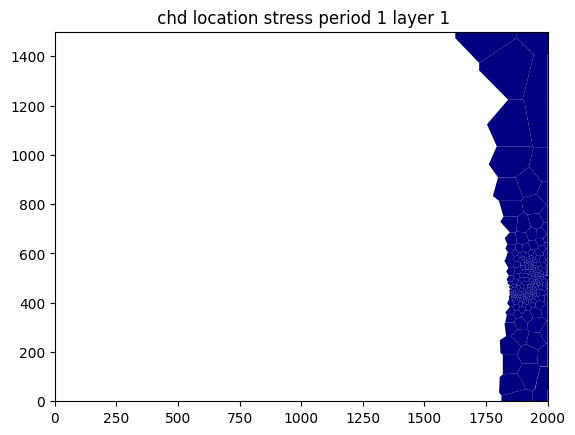

In [16]:
model.gwf.chd.plot()

In [18]:
model.cor(per=1).plot()